## Simple Notebook to Obtain the Antenna S11 for B+18 pipeline

In [36]:
from edges_cal import modelling as mdl
from edges_cal.tools import FrequencyRange
from edges_analysis.calibration.s11 import AntennaS11
import numpy as np
from astropy import units as un
import hickle
import matplotlib.pyplot as plt

In [48]:
s11freq, s11real, s11imag = np.genfromtxt("S11_blade_low_band_2015_342_03_14.txt.csv", skip_header=1,delimiter=',').T

In [49]:
s11freq = FrequencyRange(s11freq*un.Hz, f_low=50*un.MHz, f_high=100.0*un.MHz)

In [50]:
ants11 = AntennaS11(
    raw_s11 = (s11real + s11imag*1j)[s11freq.mask],  
    freq=s11freq,
    n_terms=10,
    complex_model_type=mdl.ComplexRealImagModel,
    model_type=mdl.Polynomial,
    model_transform=mdl.LogTransform(scale=1.0),
    set_transform_range=True,
    fit_kwargs={"method": "alan-qrd"},
    internal_switch=None,
).with_model_delay()

In [51]:
ants11.model_delay

<Quantity 0.0268 us>

In [52]:
alan = np.genfromtxt("/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/627/modeled_antenna_s11.txt")

In [53]:
mymod = ants11.s11_model(alan[:, 0]*un.MHz)

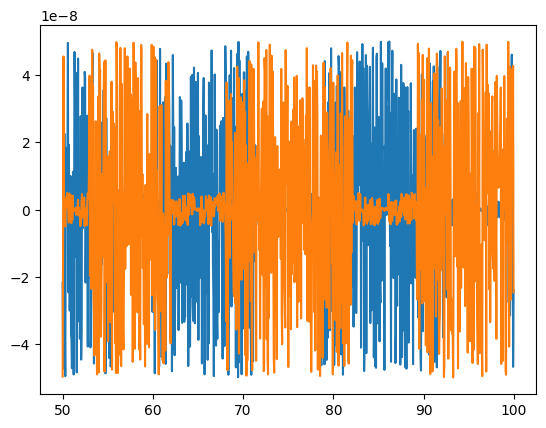

In [54]:
plt.plot(alan[:, 0], alan[:, 1] - mymod.real)
plt.plot(alan[:, 0], alan[:, 2] - mymod.imag)

In [55]:
hickle.dump(ants11, "../outputs/2015_ants11_modelled_redone.h5")

/data4/smurray/edges/.venv/lib/python3.11/site-packages/hickle/lookup.py:1491: SerializedWarning: 'slice' type not understood, data is serialized:
  warnings.warn(
/data4/smurray/edges/.venv/lib/python3.11/site-packages/hickle/lookup.py:1491: SerializedWarning: 'ABCMeta' type not understood, data is serialized:
  warnings.warn(
/data4/smurray/edges/.venv/lib/python3.11/site-packages/hickle/lookup.py:1491: SerializedWarning: 'YAMLObjectMetaclass' type not understood, data is serialized:
  warnings.warn(
